# 🌊 Rising Waters — Flood Prediction
## Notebook 1: Exploratory Data Analysis & Visualization

**Dataset:** flood dataset.xlsx — 115 records, 10 features
**Features:** Temp, Humidity, Cloud Cover, ANNUAL, Jan-Feb, Mar-May, Jun-Sep, Oct-Dec, avgjune, sub
**Target:** flood (0 = No Flood, 1 = Flood)

---
### 📦 Cell 1 — Importing Libraries

In [1]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Color palette
BLUE      = '#1F4E79'
BLUE_MID  = '#2E75B6'
BLUE_LITE = '#BDD7EE'
RED       = '#C62828'
GREEN     = '#2E7D32'

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
### 📂 Cell 2 — Loading the Dataset

In [2]:
# Load flood dataset only
df = pd.read_excel('flood dataset.xlsx')

print('✅ flood dataset.xlsx loaded successfully!')
print(f'Shape: {df.shape[0]} rows x {df.shape[1]} columns')

✅ flood dataset.xlsx loaded successfully!
Shape: 115 rows x 11 columns


---
### 🔍 Cell 3 — Descriptive Analysis

In [3]:
# head() — view first 5 records
print('=== head() — First 5 Records ===')
df.head()

=== head() — First 5 Records ===


,Temp,Humidity,Cloud Cover,ANNUAL,Jan-Feb,Mar-May,Jun-Sep,Oct-Dec,avgjune,sub,flood
0,29,70,30,3248.60,73.40,386.20,2122.80,666.10,274.87,649.90,0
1,28,75,40,3326.60,9.30,275.70,2403.40,638.20,130.30,256.40,1
2,28,75,42,3271.20,21.70,336.30,2343.00,570.10,186.20,308.90,0
3,29,71,44,3129.70,26.70,339.40,2398.20,365.30,366.07,862.50,0
4,31,74,40,2741.60,23.40,378.50,1881.50,458.10,283.40,586.90,0


In [4]:
# shape — total rows and columns
print('=== shape ===')
print(f'Rows    : {df.shape[0]}')
print(f'Columns : {df.shape[1]}')
print(f'Features: {list(df.columns)}')

=== shape ===
Rows    : 115
Columns : 11
Features: ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL', 'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub', 'flood']


In [5]:
# info() — column names, data types, null counts
print('=== info() ===')
df.info()

=== info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 115 entries, 0 to 114
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temp         115 non-null    int64  
 1   Humidity     115 non-null    int64  
 2   Cloud Cover  115 non-null    int64  
 3   ANNUAL       115 non-null    float64
 4   Jan-Feb      115 non-null    float64
 5   Mar-May      115 non-null    float64
 6   Jun-Sep      115 non-null    float64
 7   Oct-Dec      115 non-null    float64
 8   avgjune      115 non-null    float64
 9   sub          115 non-null    float64
 10  flood        115 non-null    int64  
dtypes: float64(7), int64(4)
memory usage: 10.0 KB


In [6]:
# describe() — statistical summary
print('=== describe() — Statistical Summary ===')
df.describe().T.style.background_gradient(cmap='Blues').format('{:.2f}')

=== describe() — Statistical Summary ===


,count,mean,std,min,25%,50%,75%,max
Temp,115.00,29.60,1.12,28.00,29.00,30.00,31.00,31.00
Humidity,115.00,73.85,2.95,70.00,71.00,74.00,76.00,79.00
Cloud Cover,115.00,36.29,4.33,30.00,32.50,36.00,40.00,44.00
ANNUAL,115.00,2925.49,422.11,2068.80,2627.90,2937.50,3164.10,4257.80
Jan-Feb,115.00,27.74,22.36,0.30,10.25,20.50,41.60,98.10
Mar-May,115.00,377.25,151.09,89.90,276.75,342.00,442.30,915.20
Jun-Sep,115.00,2022.84,386.25,1104.30,1768.85,1948.70,2242.90,3451.30
Oct-Dec,115.00,497.64,129.86,166.60,407.45,501.50,584.55,823.30
avgjune,115.00,218.10,62.55,65.60,179.67,211.03,263.83,366.07
sub,115.00,439.80,210.44,34.20,295.00,430.60,577.65,982.70


---
### ❓ Cell 4 — Handling Missing Values

In [7]:
# isnull().sum() — count missing per column
print('=== Missing Values per Column ===')
missing = df.isnull().sum()
print(missing)
print(f'\nTotal missing values: {missing.sum()}')

# isnull().any() — confirm if any column has missing data
print('\n=== isnull().any() ===')
print(df.isnull().any())

if missing.sum() == 0:
    print('\n✅ No missing values found in the dataset!')
else:
    print('\n⚠️  Missing values detected — filling with median...')
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col].fillna(df[col].median(), inplace=True)
    print('✅ Missing values handled!')

=== Missing Values per Column ===
Temp           0
Humidity       0
Cloud Cover    0
ANNUAL         0
Jan-Feb        0
Mar-May        0
Jun-Sep        0
Oct-Dec        0
avgjune        0
sub            0
flood          0
dtype: int64

Total missing values: 0

=== isnull().any() ===
Temp           False
Humidity       False
Cloud Cover    False
ANNUAL         False
Jan-Feb        False
Mar-May        False
Jun-Sep        False
Oct-Dec        False
avgjune        False
sub            False
flood          False
dtype: bool

✅ No missing values found in the dataset!


---
### 🎯 Cell 5 — Target Variable Distribution

Class Distribution:
  No Flood (0) : 99 records  (86.1%)
  Flood    (1) : 16 records  (13.9%)

Class imbalance ratio: 6.2:1


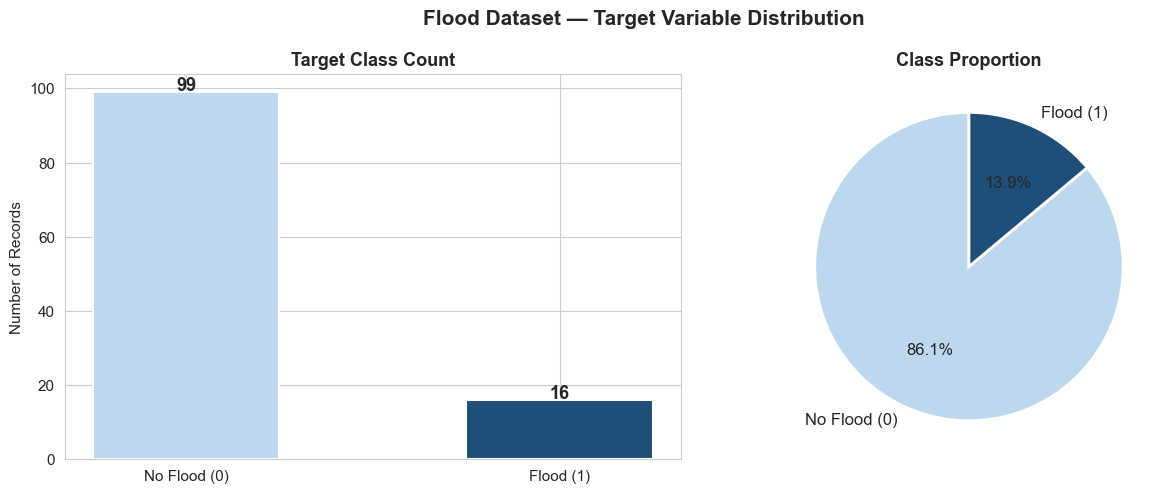

In [8]:
counts = df['flood'].value_counts()
pct    = df['flood'].value_counts(normalize=True) * 100

print('Class Distribution:')
print(f'  No Flood (0) : {counts[0]} records  ({pct[0]:.1f}%)')
print(f'  Flood    (1) : {counts[1]} records  ({pct[1]:.1f}%)')
print(f'\nClass imbalance ratio: {counts[0]/counts[1]:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Count bar chart
bars = axes[0].bar(
    ['No Flood (0)', 'Flood (1)'],
    counts.values,
    color=[BLUE_LITE, BLUE],
    edgecolor='white', linewidth=1.5, width=0.5
)
axes[0].set_title('Target Class Count', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Records')
for bar in bars:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 str(int(h)), ha='center', fontweight='bold', fontsize=13)

# Pie chart
axes[1].pie(
    counts.values,
    labels=['No Flood (0)', 'Flood (1)'],
    autopct='%1.1f%%',
    colors=[BLUE_LITE, BLUE],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 12}
)
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('Flood Dataset — Target Variable Distribution',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_01_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 📈 Cell 6 — Univariate Analysis: Distribution Plots

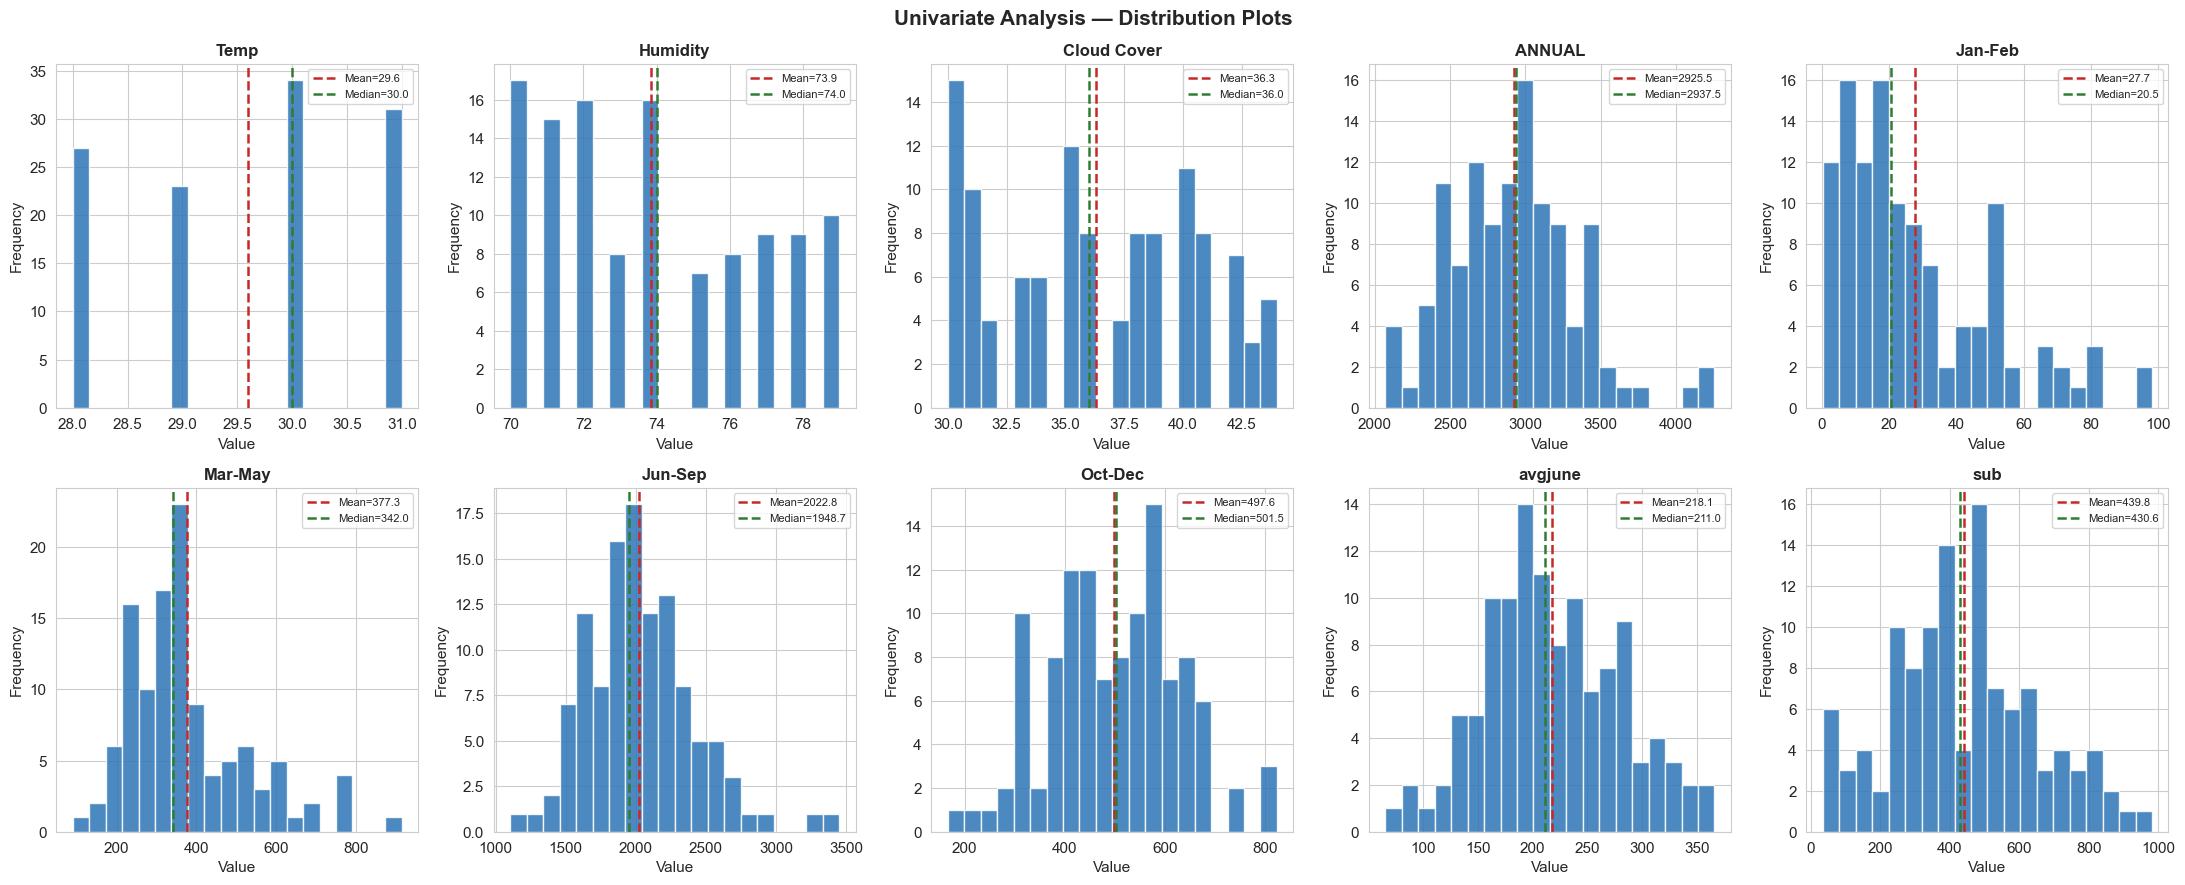

In [9]:
FEATURES = ['Temp', 'Humidity', 'Cloud Cover', 'ANNUAL',
            'Jan-Feb', 'Mar-May', 'Jun-Sep', 'Oct-Dec', 'avgjune', 'sub']

fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    axes[i].hist(df[col], bins=20, color=BLUE_MID,
                 edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color=RED, linestyle='--',
                    linewidth=1.8, label=f'Mean={df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color=GREEN, linestyle='--',
                    linewidth=1.8, label=f'Median={df[col].median():.1f}')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)

plt.suptitle('Univariate Analysis — Distribution Plots',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_distribution_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 📦 Cell 7 — Univariate Analysis: Box Plots (Outlier Detection)

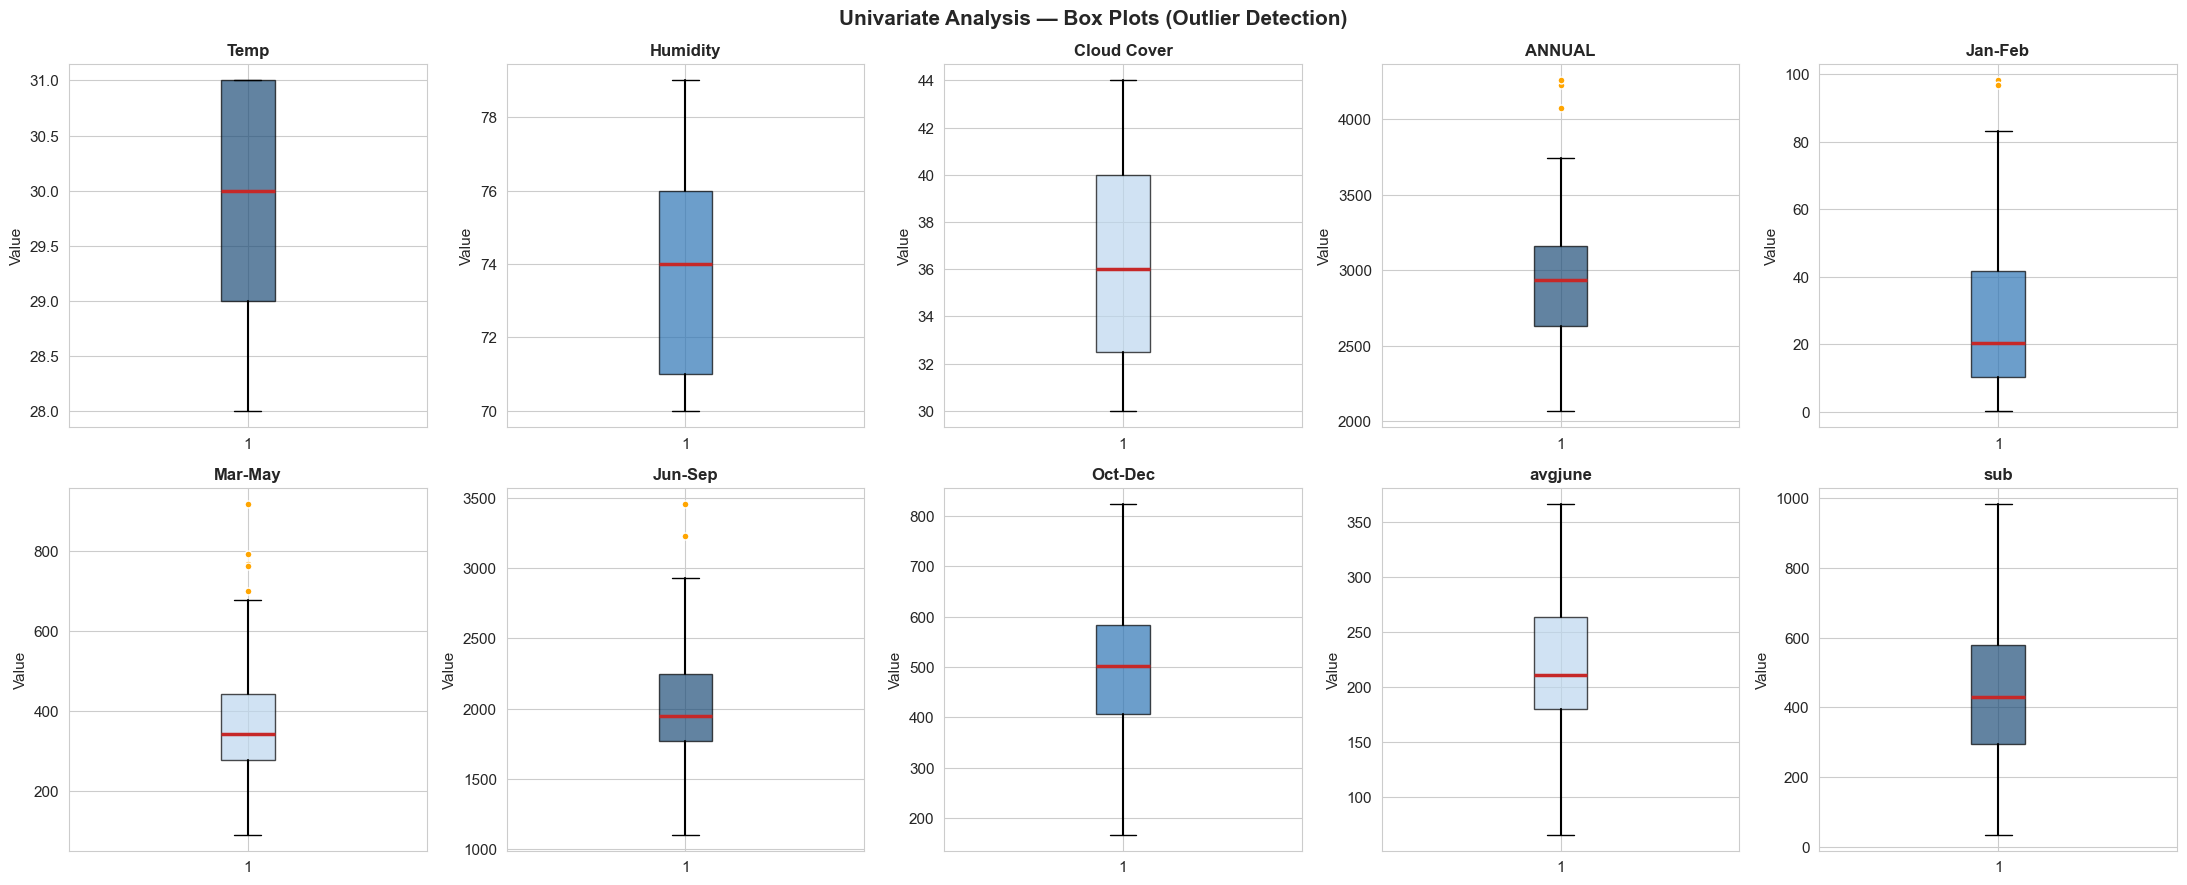

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()
palette = [BLUE, BLUE_MID, BLUE_LITE, BLUE, BLUE_MID,
           BLUE_LITE, BLUE, BLUE_MID, BLUE_LITE, BLUE]

for i, col in enumerate(FEATURES):
    axes[i].boxplot(
        df[col],
        patch_artist=True,
        boxprops=dict(facecolor=palette[i], alpha=0.7),
        medianprops=dict(color=RED, linewidth=2.5),
        whiskerprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='orange',
                        markersize=5, markeredgecolor='white')
    )
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.suptitle('Univariate Analysis — Box Plots (Outlier Detection)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

---
### 🔥 Cell 8 — Multivariate Analysis: Correlation Heatmap

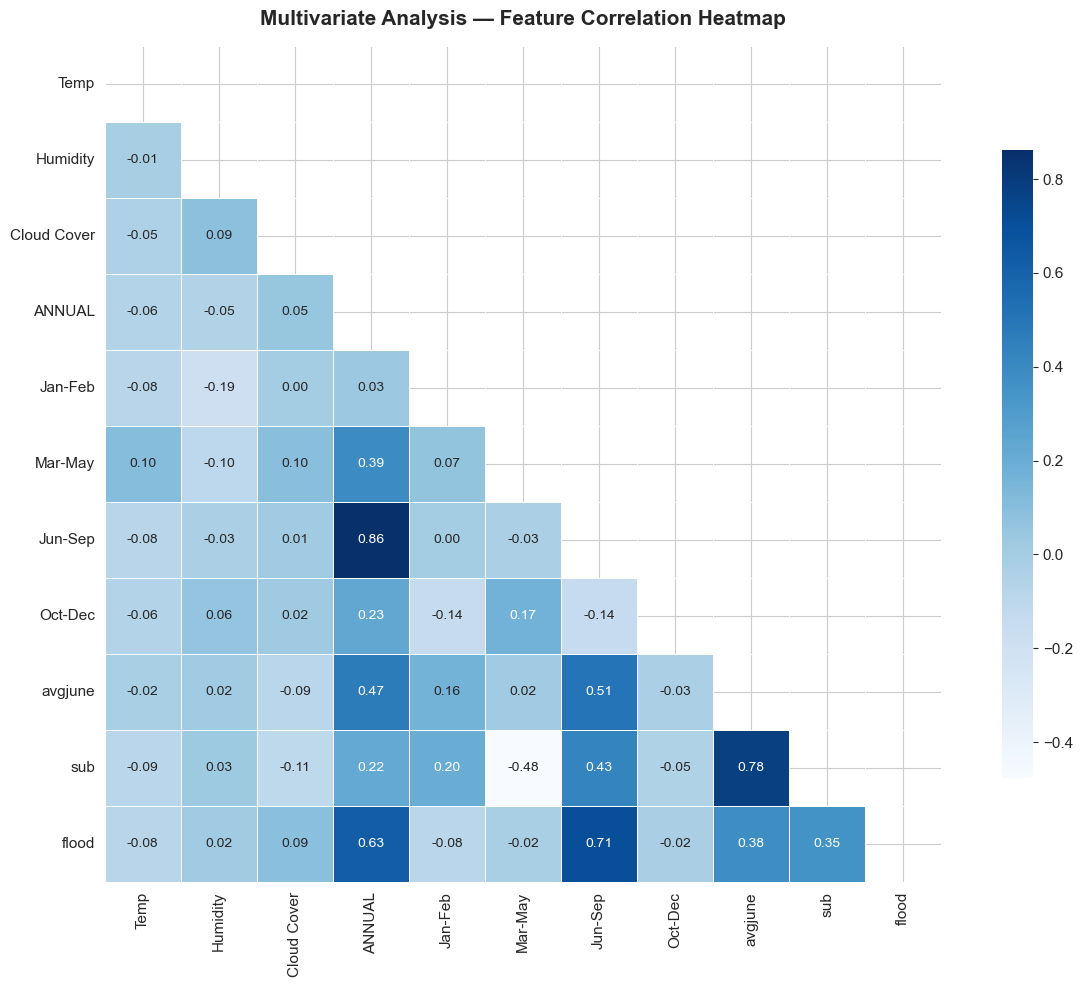


Correlation with target [flood] — sorted:
Jun-Sep        0.71
ANNUAL         0.63
avgjune        0.38
sub            0.35
Cloud Cover    0.09
Humidity       0.02
Mar-May       -0.02
Oct-Dec       -0.02
Temp          -0.08
Jan-Feb       -0.08


In [11]:
plt.figure(figsize=(13, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75},
    annot_kws={'size': 10}
)

plt.title('Multivariate Analysis — Feature Correlation Heatmap',
          fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCorrelation with target [flood] — sorted:')
print(corr['flood'].drop('flood').sort_values(ascending=False).to_string())

---
### 🎻 Cell 9 — Multivariate Analysis: Violin Plots (Feature vs Flood)

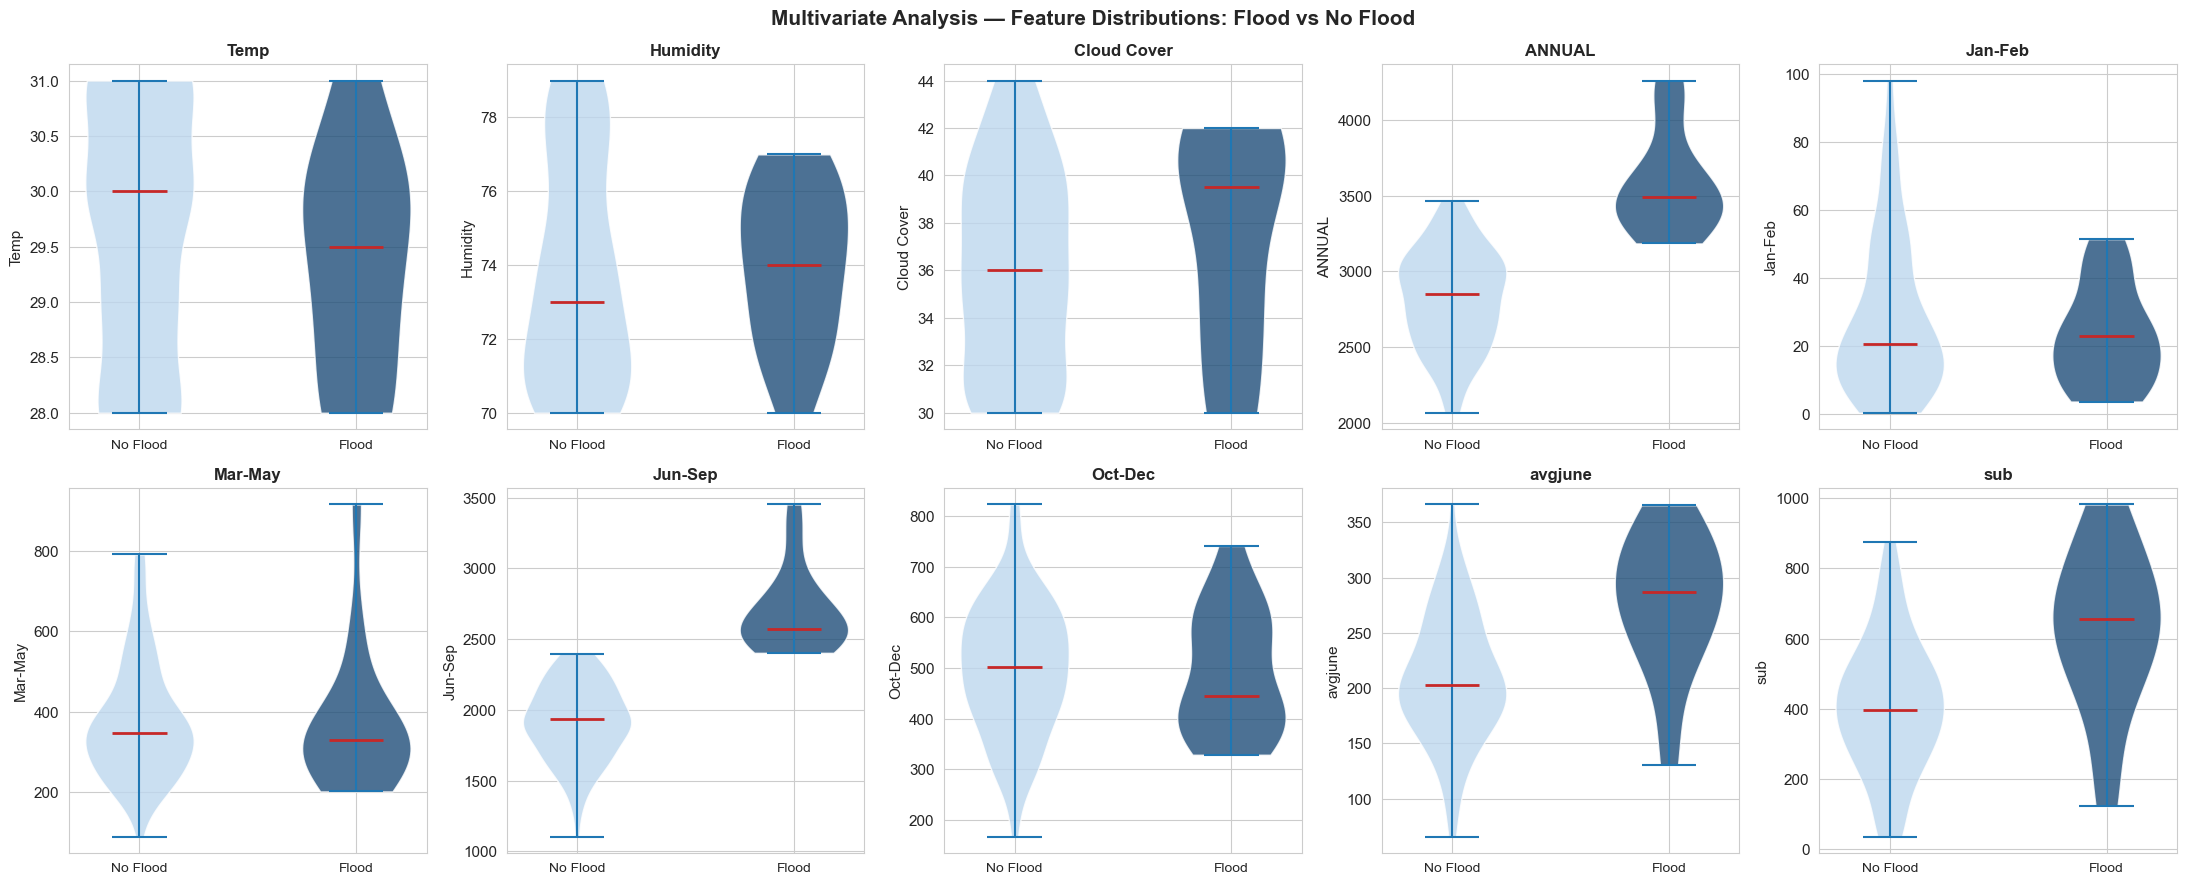

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, col in enumerate(FEATURES):
    no_flood = df[df['flood'] == 0][col].values
    flood    = df[df['flood'] == 1][col].values

    parts = axes[i].violinplot(
        [no_flood, flood],
        positions=[0, 1],
        showmedians=True,
        showextrema=True
    )
    parts['cmedians'].set_color(RED)
    parts['cmedians'].set_linewidth(2)
    for pc, c in zip(parts['bodies'], [BLUE_LITE, BLUE]):
        pc.set_facecolor(c)
        pc.set_alpha(0.8)

    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Flood', 'Flood'], fontsize=10)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel(col)

plt.suptitle('Multivariate Analysis — Feature Distributions: Flood vs No Flood',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_violin_plots.png', dpi=150, bbox_inches='tight')
plt.show()

---
### ✅ Cell 10 — EDA Summary

In [13]:
print('=' * 58)
print('              EDA SUMMARY REPORT')
print('=' * 58)
print(f'  Dataset         : flood dataset.xlsx')
print(f'  Total Records   : {df.shape[0]}')
print(f'  Total Features  : {df.shape[1] - 1}')
print(f'  Missing Values  : {df.isnull().sum().sum()}')
print(f'  Duplicate Rows  : {df.duplicated().sum()}')
print(f'  No Flood (0)    : {(df["flood"]==0).sum()} ({(df["flood"]==0).mean()*100:.1f}%)')
print(f'  Flood    (1)    : {(df["flood"]==1).sum()} ({(df["flood"]==1).mean()*100:.1f}%)')
print(f'  Imbalance Ratio : {(df["flood"]==0).sum()/(df["flood"]==1).sum():.1f}:1')
print('=' * 58)
print()
print('Plots Generated:')
print('  plot_01_target_distribution.png')
print('  plot_02_distribution_plots.png')
print('  plot_03_boxplots.png')
print('  plot_04_correlation_heatmap.png')
print('  plot_05_violin_plots.png')
print()
print('✅ EDA complete! Next step -> Run flood_model.ipynb')

              EDA SUMMARY REPORT
  Dataset         : flood dataset.xlsx
  Total Records   : 115
  Total Features  : 10
  Missing Values  : 0
  Duplicate Rows  : 0
  No Flood (0)    : 99 (86.1%)
  Flood    (1)    : 16 (13.9%)
  Imbalance Ratio : 6.2:1

Plots Generated:
  plot_01_target_distribution.png
  plot_02_distribution_plots.png
  plot_03_boxplots.png
  plot_04_correlation_heatmap.png
  plot_05_violin_plots.png

✅ EDA complete! Next step -> Run flood_model.ipynb
